In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")
sns.set_theme()

import warnings
warnings.filterwarnings("ignore")

In [3]:
leads = pd.read_csv('../data/leads (1).csv')
interactions = pd.read_csv('../data/interactions (1).csv')

print("Leads Shape:", leads.shape)
print("Interactions Shape:", interactions.shape)

Leads Shape: (2045, 21)
Interactions Shape: (40000, 36)


In [4]:
display(leads.head())

display(interactions.head())

print("\nLeads Info")
print(leads.info())

print("\nInteractions Info")
print(interactions.info())

,lead_id,source,campaign,city,state,region,device_type,browser,industry,company_size,...,annual_revenue_band,employee_count,company_age_years,funding_stage,employee_growth_band,job_role,first_touch_channel,business_email,account_type,created_at
0,LEAD-01690,Referral,Retargeting_General,Mumbai,Maharashtra,West,Mobile,Chrome,Healthcare,Large,...,10Cr-50Cr,755,15,Series A,Unknown,VP,Direct,garima.oommen@karnikltd.com,New Business,2026-02-04 11:37:23
1,LEAD-01555,Direct,Retargeting_General,Mumbai,Maharashtra,West,Desktop,Chrome,SaaS,Large,...,10Cr-50Cr,297,14,Series A,25-50%,CXO,Referral,sai.andra@yahoo.com,Partner,2026-03-06 16:13:50
2,LEAD-01284,Instagram,Startup_Founders,Mumbai,Maharashtra,West,Mobile,Opera,SaaS,Small,...,1Cr-10Cr,35,2,Bootstrapped,0-10%,Associate,Social Media - Instagram,triya.deshmukh@yahoo.com,New Business,2026-02-15 16:43:20
3,LEAD-00979,Facebook,Retargeting_General,Thane,Maharashtra,West,Mobile,Safari,Healthcare,Large,...,10Cr-50Cr,839,16,Unknown,10-25%,Manager,Display Ad,saanvi.pandey@dugarwalla.com,New Business,2026-05-28 10:12:49
4,LEAD-00259,Google,Q1_BFSI_Pune,Pune,Maharashtra,West,Mobile,Brave,BFSI,Small,...,1Cr-10Cr,38,6,Public,10-25%,Founder,Display Ad,meghana.mukherjee@rattanviswan.com,Partner,2026-01-19 15:46:33


,interaction_id,lead_id,session_id,visitor_id,timestamp,page_name,page_category,page_url,page_depth,event_type,...,screen_size,traffic_source,utm_source,utm_medium,utm_campaign,referrer_type,session_number,is_return_visitor,previous_session_gap_days,funnel_stage
0,INT-015483,LEAD-00612,S-B7F581FEC7C5,V-E3A7D06E94,2026-07-01 00:00:00,Landing Page,landing,/lp/campaign,2,track,...,360x780,linkedin,linkedin,NaN,bfsi_jan,social,1,False,NaN,Awareness
1,INT-029965,LEAD-01737,S-EDF8EFAB7165,V-571AC6DA98,2026-05-09 03:59:23,Pricing,pricing,/pricing,5,track,...,1440x900,referral,NaN,referral,startup_apr,NaN,12,True,0.0,Evaluation
2,INT-050883,LEAD-00326,S-349F82A92570,V-BC9E4D707F,2026-01-26 05:17:02,Case Studies,social_proof,/case-studies,4,track,...,360x780,google,google,cpc,startup_apr,direct,1,False,NaN,Awareness
3,INT-055123,LEAD-00369,S-E745DD98EA0C,V-585D55675D,2026-05-03 03:07:29,NaN,product,/features,3,track,...,1920x1080,google,google,cpc,product_launch,referral,4,True,28.0,Awareness
4,INT-021599,LEAD-01929,S-D05DBEC8F4D3,V-D45BFB1704,2026-01-15 03:34:26,Pricing,pricing,/pricing,5,track,...,375x667,organic,google,organic,startup_founders,search,2,True,2.0,Awareness



Leads Info
<class 'pandas.DataFrame'>
RangeIndex: 2045 entries, 0 to 2044
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   lead_id               2045 non-null   str  
 1   source                2045 non-null   str  
 2   campaign              2045 non-null   str  
 3   city                  2005 non-null   str  
 4   state                 2045 non-null   str  
 5   region                2045 non-null   str  
 6   device_type           2045 non-null   str  
 7   browser               1944 non-null   str  
 8   industry              2045 non-null   str  
 9   company_size          1944 non-null   str  
 10  lead_segment          2045 non-null   str  
 11  annual_revenue_band   2003 non-null   str  
 12  employee_count        2045 non-null   int64
 13  company_age_years     2045 non-null   int64
 14  funding_stage         2045 non-null   str  
 15  employee_growth_band  2045 non-null   str  
 16  job_r

In [5]:
missing_leads = (
    leads.isnull()
    .sum()
    .sort_values(ascending=False)
)
print("\nMissing Values in Leads:")
print(missing_leads)


Missing Values in Leads:
browser                 101
company_size            101
annual_revenue_band      42
city                     40
lead_id                   0
state                     0
campaign                  0
source                    0
region                    0
industry                  0
device_type               0
lead_segment              0
employee_count            0
company_age_years         0
funding_stage             0
employee_growth_band      0
job_role                  0
first_touch_channel       0
business_email            0
account_type              0
created_at                0
dtype: int64


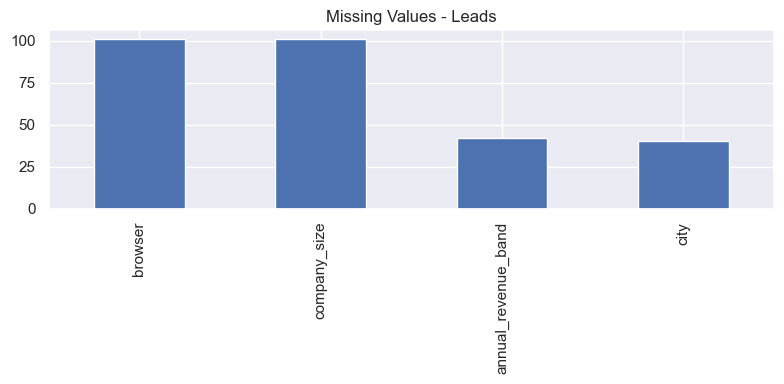

browser                101
company_size           101
annual_revenue_band     42
city                    40
dtype: int64

In [ ]:
missing_leads = missing_leads[missing_leads > 0]
plt.figure(figsize=(8,4))
missing_leads.plot(kind="bar")
plt.title("Missing Values - Leads")
plt.tight_layout()
plt.savefig("../outputs/eda/missing_values_leads.png")
plt.show()

missing_leads

In [8]:
print("Duplicate lead_ids:", leads["lead_id"].duplicated().sum())

print("Unique lead_ids:", leads["lead_id"].nunique())

print("Total rows:", len(leads))

Duplicate lead_ids: 20
Unique lead_ids: 2025
Total rows: 2045


In [9]:
duplicate_ids = leads[
    leads["lead_id"].duplicated(keep=False)
].sort_values("lead_id")

print("Duplicate Records:")
display(duplicate_ids.head(20))

Duplicate Records:


,lead_id,source,campaign,city,state,region,device_type,browser,industry,company_size,...,annual_revenue_band,employee_count,company_age_years,funding_stage,employee_growth_band,job_role,first_touch_channel,business_email,account_type,created_at
584,LEAD-00100,Google,Q1_BFSI_Pune,Pune,Maharashtra,West,Mobile,Chrome,SaaS,Enterprise,...,100Cr+,9048,22,Unknown,25-50%,VP,Organic Search,oeshi.reddy@yahoo.com,New Business,2026-02-27 19:28:05
2013,LEAD-00100,Google,Q1_BFSI_Pune,Pune,Maharashtra,West,Mobile,Chrome,SaaS,Enterprise,...,100Cr+,9048,22,Unknown,25-50%,VP,Organic Search,oeshi.reddy@yahoo.com,New Business,2026-02-27 19:28:05
353,LEAD-00121,Google,Q1_BFSI_Mumbai,Thane,Maharashtra,West,Desktop,Safari,Education,Large,...,50Cr-100Cr,972,11,Series C+,0-10%,Senior Manager,Display Ad,patrick.vig@outlook.com,Existing Customer,2026-01-31 13:35:59
2001,LEAD-00121,Google,Q1_BFSI_Mumbai,Thane,Maharashtra,West,Desktop,Safari,Education,Large,...,50Cr-100Cr,972,11,Series C+,0-10%,Senior Manager,Display Ad,patrick.vig@outlook.com,Existing Customer,2026-01-31 13:35:59
2012,LEAD-00162,Google,Q1_BFSI_Pune,Mumbai,Maharashtra,West,Mobile,Chrome,Technology,Medium,...,10Cr-50Cr,93,4,Series B,0-10%,Associate,Organic Search,jack.raval@yahoo.com,Partner,2026-01-05 13:16:15
1118,LEAD-00162,Google,Q1_BFSI_Pune,Mumbai,Maharashtra,West,Mobile,Chrome,Technology,Medium,...,10Cr-50Cr,93,4,Series B,0-10%,Associate,Organic Search,jack.raval@yahoo.com,Partner,2026-01-05 13:16:15
128,LEAD-00361,Google,Brand_Awareness,Hyderabad,Telangana,South,Desktop,Chrome,Manufacturing,Large,...,10Cr-50Cr,805,16,Unknown,25-50%,Manager,Display Ad,charan.hayer@outlook.com,Existing Customer,2026-05-10 14:46:11
2017,LEAD-00361,Google,Brand_Awareness,Hyderabad,Telangana,South,Desktop,Chrome,Manufacturing,Large,...,10Cr-50Cr,805,16,Unknown,25-50%,Manager,Display Ad,charan.hayer@outlook.com,Existing Customer,2026-05-10 14:46:11
2007,LEAD-00411,Google,SaaS_Enterprise_Q1,Hyderabad,Telangana,South,Desktop,Chrome,Consulting,Medium,...,10Cr-50Cr,76,5,Series A,0-10%,Manager,Paid Search,kevin.varghese@gmail.com,New Business,2026-01-05 15:24:45
1731,LEAD-00411,Google,SaaS_Enterprise_Q1,Hyderabad,Telangana,South,Desktop,Chrome,Consulting,Medium,...,10Cr-50Cr,76,5,Series A,0-10%,Manager,Paid Search,kevin.varghese@gmail.com,New Business,2026-01-05 15:24:45


In [10]:
print(
    leads["source"]
    .value_counts()
)

source
Google            510
LinkedIn          404
Facebook          310
Direct            204
Instagram         204
Referral          167
Email Campaign    141
Organic Search    105
Name: count, dtype: int64


In [ ]:
high_intent_events = {
    "demo_request",
    "free_trial_start",
    "contact_form_submit"
}

converted_event = interactions["event_name"].isin(high_intent_events)

converted_form = interactions["form_completed"] == True

converted_leads = set(
    interactions.loc[
        converted_event | converted_form,
        "lead_id"
    ]
)

leads["converted"] = (
    leads["lead_id"]
    .isin(converted_leads)
    .astype(int)
)

print(
    "Conversion Rate:",
    round(
        leads["converted"].mean()*100,
        2
    ),
    "%"
)

Conversion Rate: 31.93 %


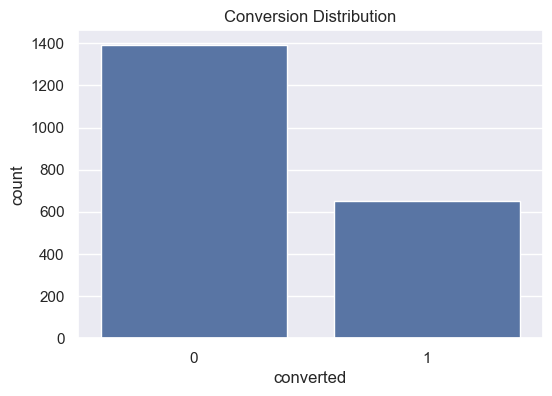

In [ ]:
plt.figure(figsize=(6,4))

sns.countplot(
    x="converted",
    data=leads
)

plt.title("Conversion Distribution")

plt.savefig(
    "../outputs/eda/conversion_distribution.png"
)

plt.show()

In [15]:
categorical_cols = [
    "city",
    "browser",
    "company_size",
    "annual_revenue_band"
]

for col in categorical_cols:
    if col in leads.columns:
        leads[col] = leads[col].fillna("Unknown")

print(
    leads[categorical_cols]
    .isnull()
    .sum() )

city                   0
browser                0
company_size           0
annual_revenue_band    0
dtype: int64


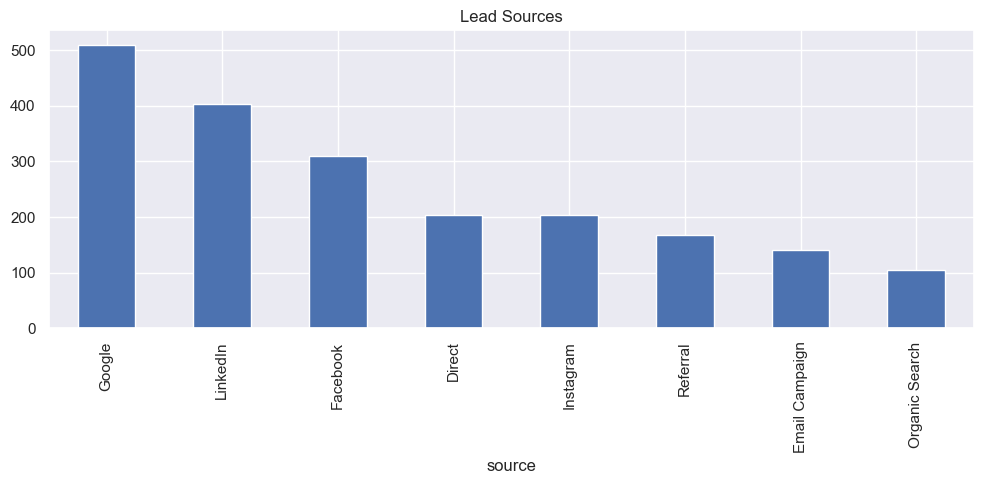

In [ ]:
plt.figure(figsize=(10,5))

leads["source"].value_counts().plot(
    kind="bar"
)

plt.title("Lead Sources")

plt.tight_layout()

plt.savefig(
    "../outputs/eda/source_distribution.png"
)

plt.show()

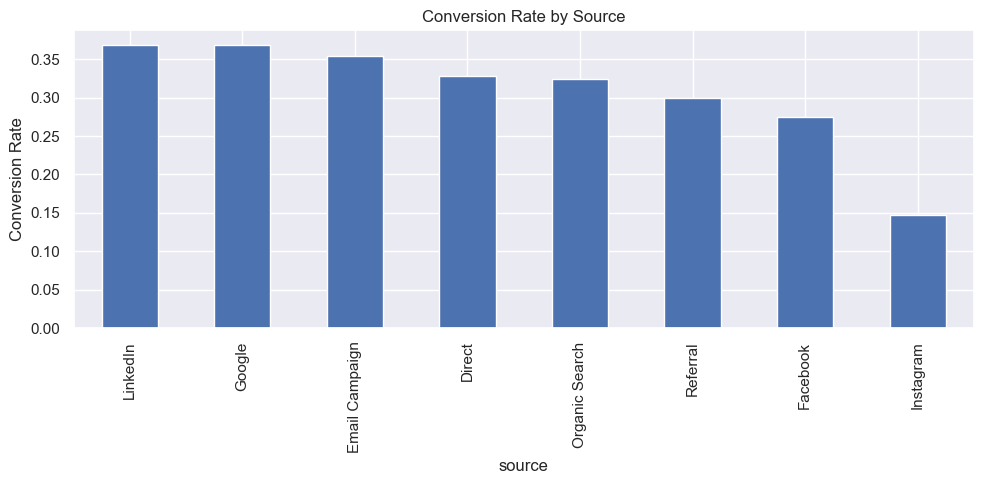

source
LinkedIn          0.368812
Google            0.368627
Email Campaign    0.354610
Direct            0.328431
Organic Search    0.323810
Referral          0.299401
Facebook          0.274194
Instagram         0.147059
Name: converted, dtype: float64

In [ ]:
source_conv = (
    leads
    .groupby("source")["converted"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10,5))

source_conv.plot(kind="bar")

plt.title("Conversion Rate by Source")

plt.ylabel("Conversion Rate")

plt.tight_layout()

plt.savefig(
    "../outputs/eda/conversion_by_source.png"
)

plt.show()

source_conv

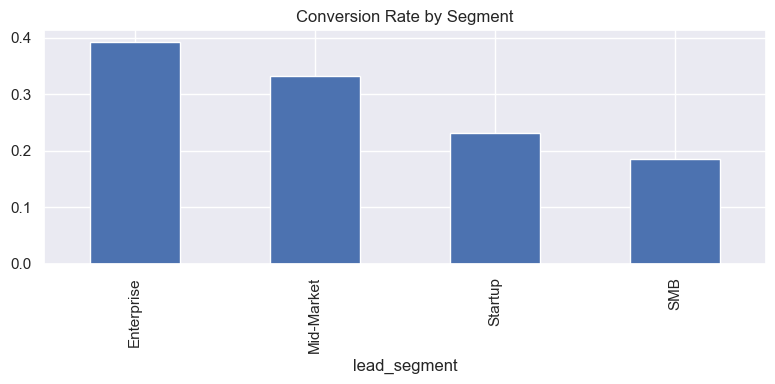

In [ ]:
segment_conv = (
    leads
    .groupby("lead_segment")["converted"]
    .mean()
    .sort_values(ascending=False)
)

segment_conv.plot(
    kind="bar",
    figsize=(8,4)
)

plt.title(
    "Conversion Rate by Segment"
)

plt.tight_layout()

plt.savefig(
    "../outputs/eda/conversion_by_segment.png"
)

plt.show()

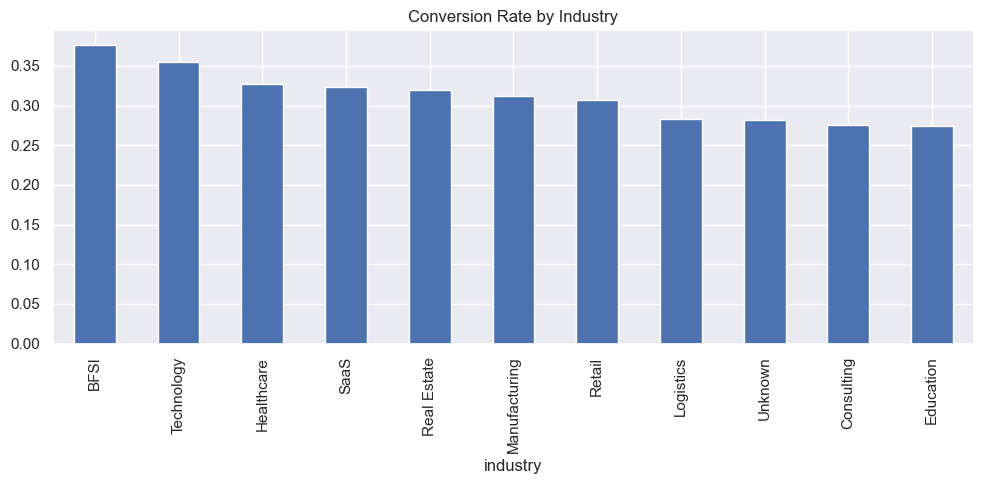

In [ ]:
industry_conv = (
    leads
    .groupby("industry")["converted"]
    .mean()
    .sort_values(ascending=False)
)

industry_conv.plot(
    kind="bar",
    figsize=(10,5)
)

plt.title(
    "Conversion Rate by Industry"
)

plt.tight_layout()

plt.savefig(
    "../outputs/eda/conversion_by_industry.png"
)

plt.show()

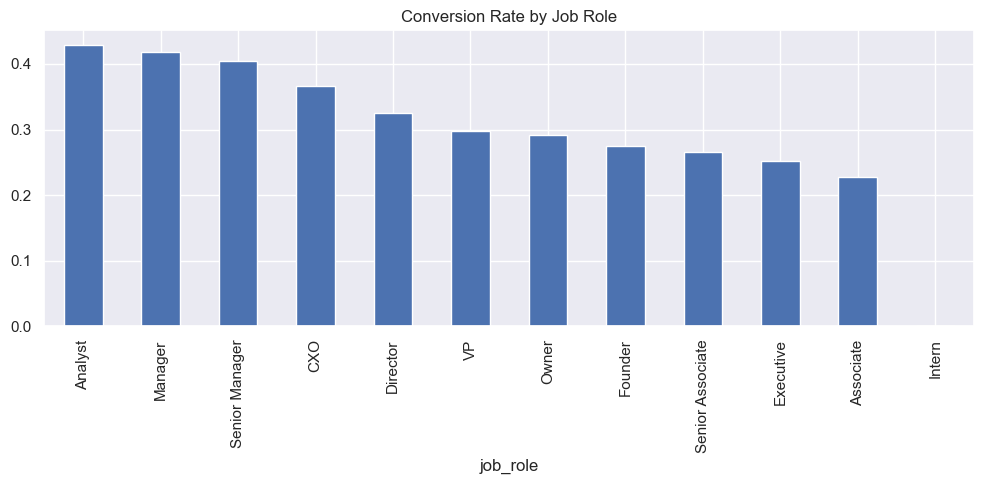

In [ ]:
job_conv = (
    leads
    .groupby("job_role")["converted"]
    .mean()
    .sort_values(ascending=False)
)

job_conv.plot(
    kind="bar",
    figsize=(10,5)
)

plt.title(
    "Conversion Rate by Job Role"
)

plt.tight_layout()

plt.savefig(
    "../outputs/eda/conversion_by_job_role.png"
)

plt.show()

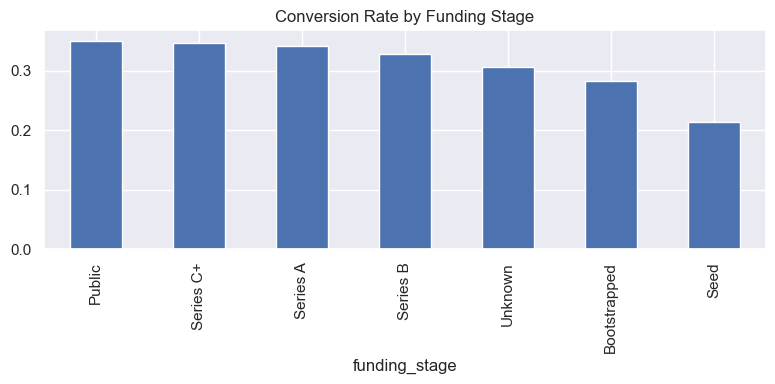

In [ ]:
funding_conv = (
    leads
    .groupby("funding_stage")["converted"]
    .mean()
    .sort_values(ascending=False)
)

funding_conv.plot(
    kind="bar",
    figsize=(8,4)
)

plt.title(
    "Conversion Rate by Funding Stage"
)

plt.tight_layout()

plt.savefig(
    "../outputs/eda/conversion_by_funding_stage.png"
)

plt.show()

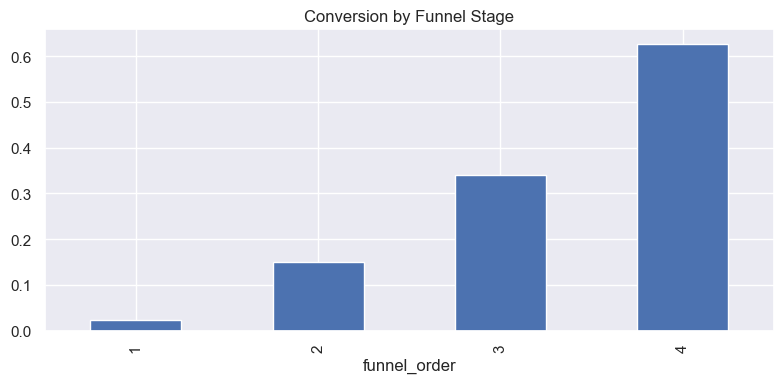

In [ ]:
funnel_order = {
    "Awareness":1,
    "Consideration":2,
    "Evaluation":3,
    "Decision":4
}

interactions["funnel_order"] = (
    interactions["funnel_stage"]
    .map(funnel_order)
)

lead_funnel = (
    interactions
    .groupby("lead_id")["funnel_order"]
    .max()
    .reset_index()
)

lead_funnel = lead_funnel.merge(
    leads[["lead_id","converted"]],
    on="lead_id"
)

funnel_conv = (
    lead_funnel
    .groupby("funnel_order")["converted"]
    .mean()
)

funnel_conv.plot(
    kind="bar",
    figsize=(8,4)
)

plt.title(
    "Conversion by Funnel Stage"
)

plt.tight_layout()

plt.savefig(
    "../outputs/eda/funnel_conversion.png"
)

plt.show()

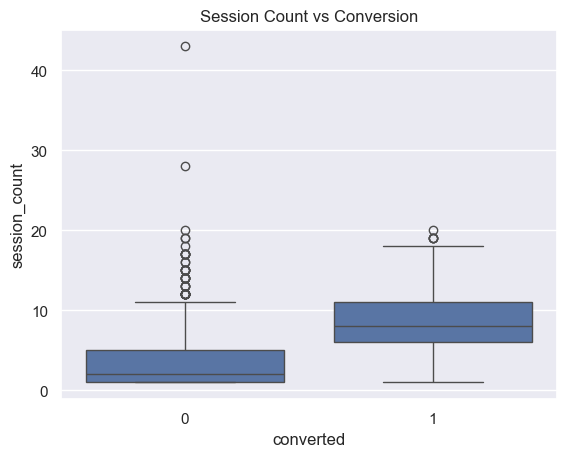

In [ ]:
sessions = (
    interactions
    .groupby("lead_id")
    .agg(
        session_count=(
            "session_id",
            "nunique"
        )
    )
    .reset_index()
)

merged = leads.merge(
    sessions,
    on="lead_id",
    how="left"
)

sns.boxplot(
    x="converted",
    y="session_count",
    data=merged
)

plt.title(
    "Session Count vs Conversion"
)

plt.savefig(
    "../outputs/eda/session_behavior.png"
)

plt.show()


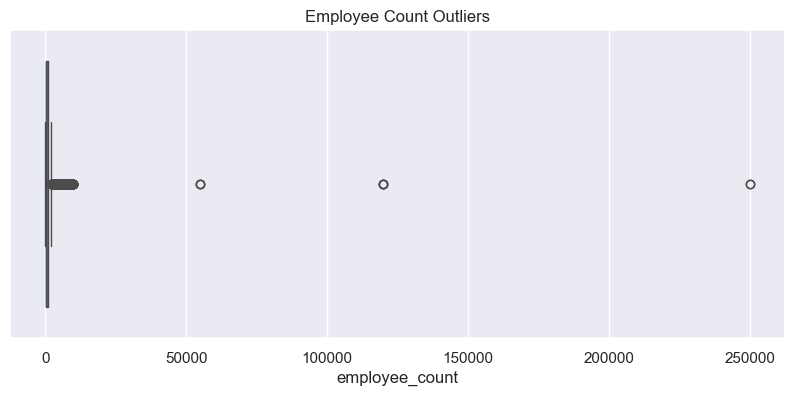

count      2045.000000
mean       2024.102689
std        9898.035371
min           1.000000
25%         109.000000
50%         348.000000
75%         939.000000
max      250000.000000
Name: employee_count, dtype: float64

In [ ]:
plt.figure(figsize=(10,4))

sns.boxplot(
    x=leads["employee_count"]
)

plt.title(
    "Employee Count Outliers"
)

plt.savefig(
    "../outputs/eda/employee_outliers.png"
)

plt.show()

leads["employee_count"].describe()



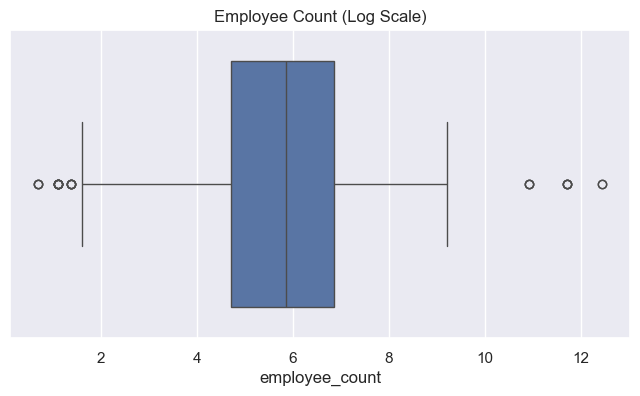

In [ ]:

plt.figure(figsize=(8,4))

sns.boxplot(
    x=np.log1p(leads["employee_count"])
)

plt.title(
    "Employee Count (Log Scale)"
)

plt.savefig(
    "../outputs/eda/employee_count_log.png"
)

plt.show()


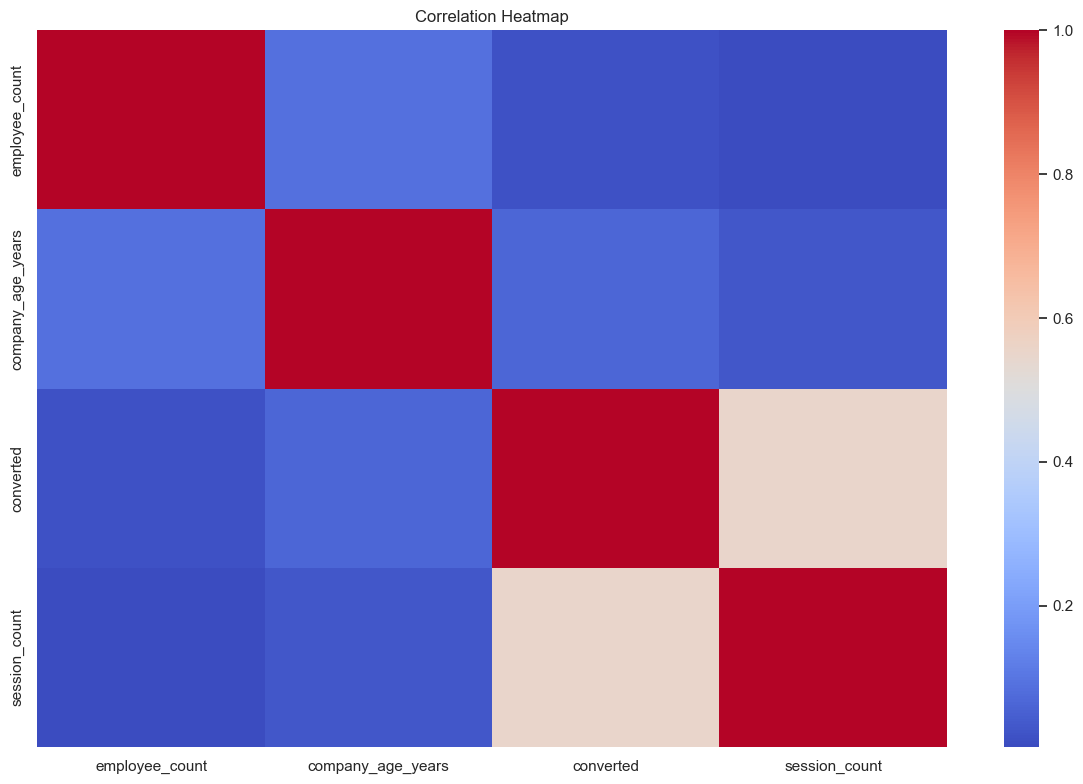

In [ ]:
numeric_cols = merged.select_dtypes(
    include=np.number
)

plt.figure(figsize=(12,8))

sns.heatmap(
    numeric_cols.corr(),
    cmap="coolwarm"
)

plt.title(
    "Correlation Heatmap"
)

plt.tight_layout()

plt.savefig(
    "../outputs/eda/correlation_heatmap.png"
)

plt.show()